In [1]:
import torch
import numpy as np
from rl4evrp.utils import evaluate_agent

import sys
from pathlib import Path

# Add framework to path
framework_path = Path.cwd()
sys.path.insert(0, str(framework_path))

# Import RL4EVRP framework
import rl4evrp as rl

print("✓ RL4EVRP framework imported successfully")

✓ RL4EVRP framework imported successfully


In [2]:
# Initialize framework with configs
framework = rl.RL4EVRP()

# Read configurations from YAML files
problem_config = framework.read_yaml('problem')
model_config = framework.read_yaml('model')
env_config = framework.read_yaml('env')

print("Problem Configuration:")
framework.config.print_config()

✓ Device: cpu
✓ Output directory: results_xai
Problem Configuration:

[ENV]
device: cuda
output_directory: results_xai
log_level: INFO
save_checkpoints: True
checkpoint_interval: 100
llm:
  enabled: False
  provider: groq
  model: llama3-8b-8192
  api_key: ${GROQ_API_KEY}
  timeout: 30
reward_tuning:
  charger_visit_penalty: 0.05
  early_return_penalty: 0.3
  service_bonus: 0.2
  completion_bonus: 2.0
  battery_violation_penalty: 1.0
diagnostics:
  track_masked_actions: True
  warn_on_violations: False
reproducibility:
  seed: 42
  deterministic: True

[MODEL]
encoder:
  type: gat
  embed_dim: 128
  n_heads: 8
  n_layers: 3
  ff_dim: 256
  dropout: 0.0
  layer_norm: True
decoder:
  type: cross_attention
  embed_dim: 128
  n_heads: 8
value_head:
  hidden_dim: 64
  activation: gelu
training:
  optimizer: adam
  lr: 0.0003
  epsilon: 1e-05
  weight_decay: 0.0
  scheduler: cosine_annealing
  T_max: 800
  eta_min_factor: 0.1
  grad_clip_norm: 1.0
  gamma: 0.99
  entropy_coefficient: 0.01
  


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\site-packages\traitlets\config\application.py", line 1075, in launch_in

In [3]:
# Build model using builder pattern
model_builder = framework.build()

# Create A2C agent (contains encoder + decoder)
model = model_builder.complete_model()

print(f"Model device: {model.device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

✓ Agent initialized with 487553 parameters
Model device: cpu
Total parameters: 487,553


In [5]:
import numpy as np

# Generate training and evaluation instances
instance_cfg = problem_config['instance_generation']
n_train = instance_cfg.get('train_size', instance_cfg.get('n_train_instances', 50000))
n_eval = instance_cfg.get('eval_size', instance_cfg.get('n_eval_instances', 100))
seed_offset = instance_cfg.get('seed_offset', 0)

train_instances = [
    framework.generate_instance(seed=seed_offset + i)
    for i in range(n_train)
]

eval_instances = [
    framework.generate_instance(seed=1000 + seed_offset + i)
    for i in range(n_eval)
]

print(f"✓ Generated {len(train_instances)} training instances")
print(f"✓ Generated {len(eval_instances)} evaluation instances")

# Example instance
demo_inst = train_instances[0]
print(f"\nExample instance:")
print(f"  Nodes: {demo_inst['n_nodes']}")
print(f"  Chargers: {(demo_inst['node_types'] == 2).sum()}")
print(f"  Customers: {(demo_inst['node_types'] == 1).sum()}")

✓ Generated 50000 training instances
✓ Generated 100 evaluation instances

Example instance:
  Nodes: 21
  Chargers: 5
  Customers: 15


In [4]:
# Load the trained model
model = model_builder.complete_model()
model.load_state_dict(torch.load('agent_episode_26800.pt', map_location=framework.device))
model.eval()


✓ Agent initialized with 487553 parameters


A2CAgent(
  (encoder): EVRPEncoder(
    (embed): Linear(in_features=7, out_features=128, bias=True)
    (layers): ModuleList(
      (0-2): 3 x GATEncoderLayer(
        (attn): MultiHeadAttention(
          (W_q): Linear(in_features=128, out_features=128, bias=False)
          (W_k): Linear(in_features=128, out_features=128, bias=False)
          (W_v): Linear(in_features=128, out_features=128, bias=False)
          (W_o): Linear(in_features=128, out_features=128, bias=False)
        )
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (ff): Sequential(
          (0): Linear(in_features=128, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=256, out_features=128, bias=True)
        )
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (decoder): EVRPDecoder(
    (proj_ctx): Linear(in_features=130, out_features=128, bias=True)
    (cross_attn): MultiHeadAttention(
     

In [8]:

# ============================================
# 1. EVRP evaluation (trained domain)
# ============================================
evrp_stats = evaluate_agent(
    model,
    eval_instances,
    device=str(framework.device),
    greedy=True,
    n_eval=len(eval_instances)  # use all eval instances, not just 20
)
print("EVRP Results:")
print(f"  Distance: {evrp_stats['mean_distance']:.3f} ± {evrp_stats['std_distance']:.3f}")

# ============================================
# 2. Nearest-neighbor baseline (same instances)
# ============================================
from rl4evrp.environment import EVRPEnv  # adjust import to your actual env path

nn_distances = []
for inst in eval_instances:
    env = EVRPEnv(inst, reward_mode='distance')
    env.reset()
    done = False
    while not done:
        vm = env._valid_mask()
        v = np.where(vm)[0]
        _, _, done, info = env.step(v[env.D[env.cur, v].argmin()])
    nn_distances.append(env.total_d)

nn_distances = np.array(nn_distances)
print(f"\nNN Baseline:")
print(f"  Distance: {nn_distances.mean():.3f} ± {nn_distances.std():.3f}")

# ============================================
# 3. Gap
# ============================================
gap = (evrp_stats['mean_distance'] - nn_distances.mean()) / nn_distances.mean() * 100
print(f"\nModel vs NN: {gap:+.1f}%")

# ============================================
# 4. CVRP test (zero-shot transfer)
#    Generate instances WITHOUT chargers and battery
# ============================================
#from rl4evrp.instance import generate_instance  # adjust import

cvrp_instances = []
for i in range(100):
    #inst = generate_instance(20, seed=i + 1000)
    framework.generate_instance(seed=i + 1000)
    # Zero out charger/battery features to make it CVRP
    # Option A: If your generate_instance supports a variant flag:
    # inst = generate_instance(20, seed=i+1000, variant='cvrp')
    
    # Option B: Manually disable EVRP features
    inst['battery_capacity'] = 99999.0  # effectively infinite
    # Remove charger nodes if possible, or set charger_prob=0
    cvrp_instances.append(inst)

cvrp_stats = evaluate_agent(
    model,
    cvrp_instances,
    device=str(framework.device),
    greedy=True,
    n_eval=len(cvrp_instances)
)
print(f"\nCVRP (zero-shot transfer):")
print(f"  Distance: {cvrp_stats['mean_distance']:.3f} ± {cvrp_stats['std_distance']:.3f}")

EVRP Results:
  Distance: 8.042 ± 1.247

NN Baseline:
  Distance: 17.999 ± 10.520

Model vs NN: -55.3%

CVRP (zero-shot transfer):
  Distance: 8.661 ± 0.000


✓ Agent initialized with 487553 parameters


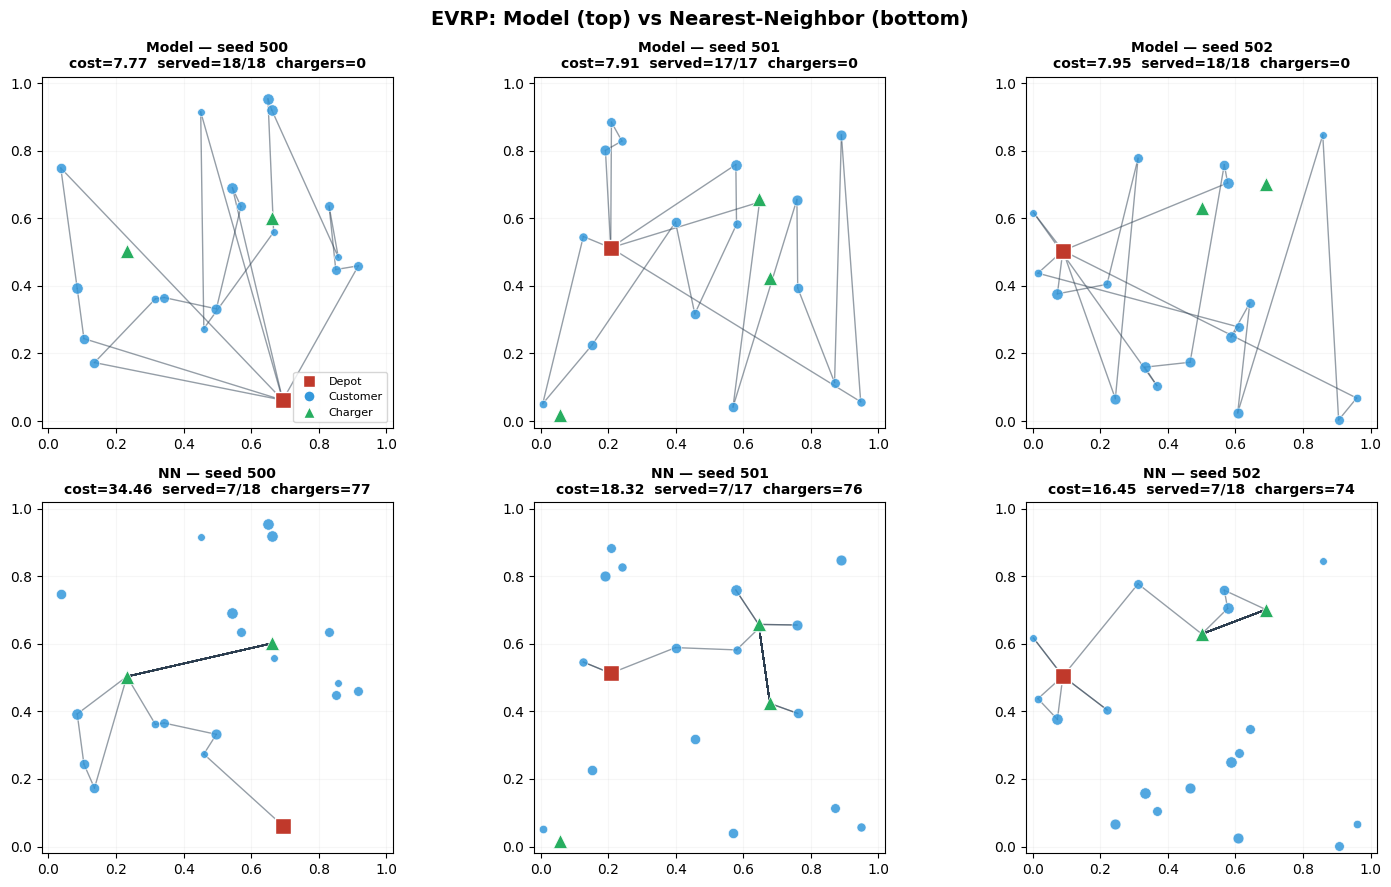

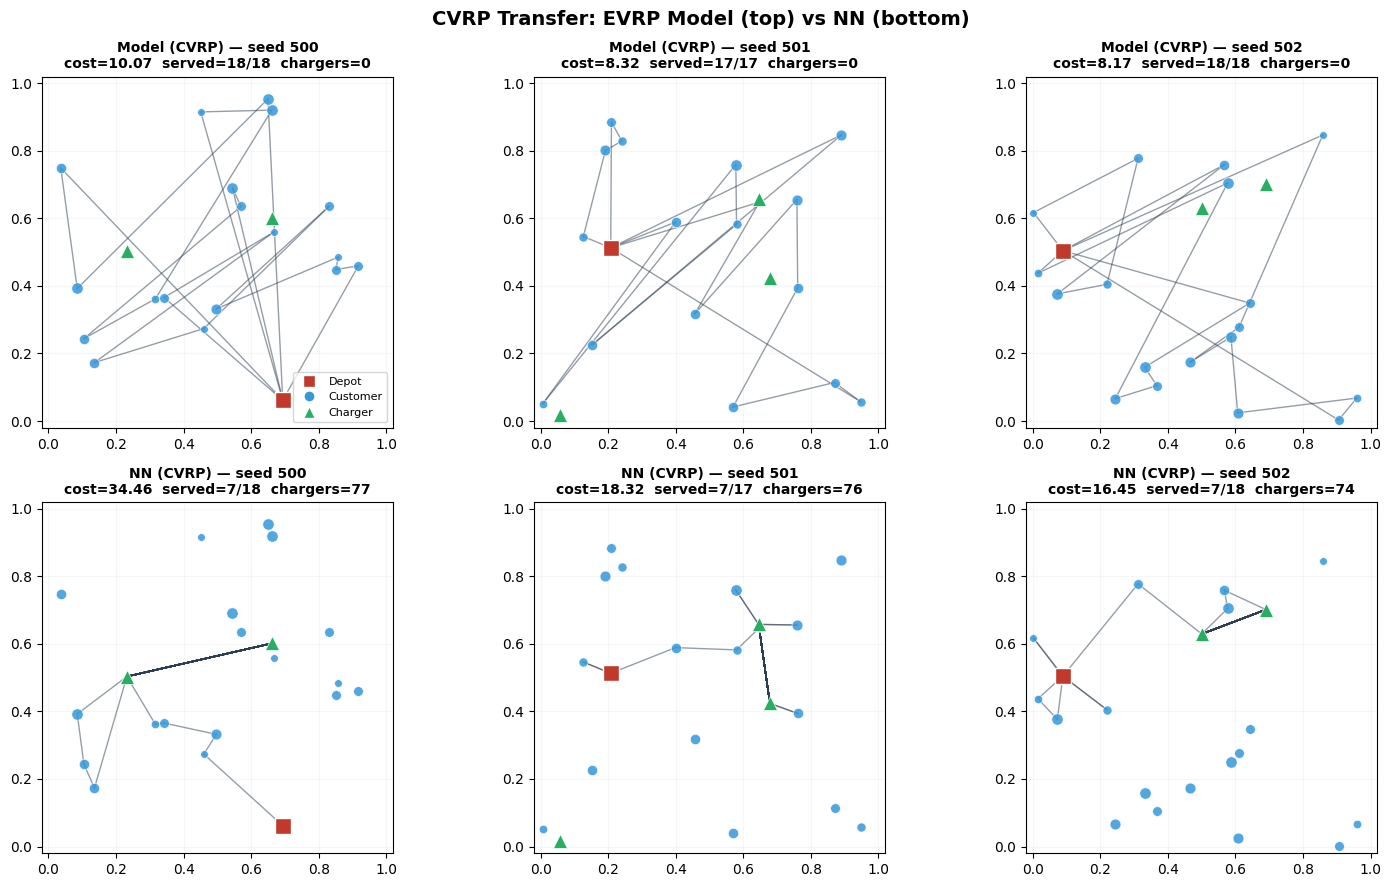

In [26]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from rl4evrp.utils import evaluate_agent
from rl4evrp.environment import EVRPEnv
#from rl4evrp.instance import generate_instance
from rl4evrp.utils import run_episode

# ============================================
# Run model on one instance, return route info
# ============================================

def run_model_episode(agent, instance, device='cpu'):
    inst = dict(instance, reward_mode='distance')
    with torch.no_grad():
        _, _, total_dist, info, _, _, env = run_episode(agent, inst, greedy=True)
    return {
        'route': env.route,
        'total_dist': env.total_d,
        'n_served': info.get('n_customers_served', 0),
        'charger_visits': info.get('charger_visits', 0),
        'battery_log': env.battery_log,
    }

def run_nn_episode(instance):
    inst = dict(instance, reward_mode='distance')
    env = EVRPEnv(inst, reward_mode='distance')
    env.reset()
    done = False
    route = [env.cur]
    battery_log = [env.battery]  # fixed

    while not done:
        vm = env._valid_mask()
        v = np.where(vm)[0]
        action = v[env.D[env.cur, v].argmin()]
        _, _, done, info = env.step(action)
        route.append(action)
        battery_log.append(env.battery)  # fixed

    return {
        'route': route,
        'total_dist': env.total_d,
        'n_served': info.get('n_customers_served', 0),
        'charger_visits': info.get('charger_visits', 0),
        'battery_log': battery_log,
    }


# ============================================
# Plot one route
# ============================================
def plot_route(ax, instance, result, title):
    coords = instance['coords']
    node_types = instance['node_types']
    demands = instance['demands']
    route = result['route']

    # Route lines
    for i in range(len(route) - 1):
        x0, y0 = coords[route[i]]
        x1, y1 = coords[route[i + 1]]
        ax.plot([x0, x1], [y0, y1], color='#2c3e50', linewidth=1.0, alpha=0.5)

    # Nodes
    for i in range(len(coords)):
        x, y = coords[i]
        if node_types[i] == 0:
            ax.plot(x, y, 's', color='#c0392b', markersize=12,
                    markeredgecolor='white', markeredgewidth=1, zorder=5)
        elif node_types[i] == 2:
            ax.plot(x, y, '^', color='#27ae60', markersize=10,
                    markeredgecolor='white', markeredgewidth=0.5, zorder=5)
        else:
            size = 25 + demands[i] * 6
            ax.scatter(x, y, s=size, c='#3498db', zorder=4,
                       edgecolors='white', linewidth=0.5, alpha=0.85)

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')

    n_cust = int((np.array(node_types) == 1).sum())
    ax.set_title(f"{title}\ncost={result['total_dist']:.2f}  "
                 f"served={result['n_served']}/{n_cust}  "
                 f"chargers={result['charger_visits']}", fontsize=10, fontweight='bold')
    ax.grid(alpha=0.1)


# ============================================
# MAIN: Generate 3 instances, compare model vs NN
# ============================================

# Load model
model = model_builder.complete_model()
model.load_state_dict(torch.load('agent_episode_26800.pt', map_location=framework.device))
model.eval()

seeds_to_show = [500, 501, 502]
legend_els = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#c0392b', markersize=8, label='Depot'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='Customer'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#27ae60', markersize=8, label='Charger'),
]

# --- EVRP ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('EVRP: Model (top) vs Nearest-Neighbor (bottom)', fontsize=14, fontweight='bold')

for col, seed in enumerate(seeds_to_show):
    inst = framework.generate_instance(seed=seed)

    model_result = run_model_episode(model, inst, str(framework.device))
    plot_route(axes[0, col], inst, model_result, f'Model — seed {seed}')

    nn_result = run_nn_episode(inst)
    plot_route(axes[1, col], inst, nn_result, f'NN — seed {seed}')

axes[0, 0].legend(handles=legend_els, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('route_comparison_evrp.pdf', dpi=300, bbox_inches='tight')
plt.show()

# --- CVRP transfer ---
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 9))
fig2.suptitle('CVRP Transfer: EVRP Model (top) vs NN (bottom)', fontsize=14, fontweight='bold')

for col, seed in enumerate(seeds_to_show):
    inst = framework.generate_instance(seed=seed)
    inst['battery_cap'] = 99999.0  # disable battery → effectively CVRP

    model_result = run_model_episode(model, inst, str(framework.device))
    plot_route(axes2[0, col], inst, model_result, f'Model (CVRP) — seed {seed}')

    nn_result = run_nn_episode(inst)
    plot_route(axes2[1, col], inst, nn_result, f'NN (CVRP) — seed {seed}')

axes2[0, 0].legend(handles=legend_els, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('route_comparison_cvrp_transfer.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def make_cvrp_instance(evrp_instance):
    """Convert EVRP instance to pure CVRP: remove chargers, disable battery."""
    inst = dict(evrp_instance)
    
    # Find customer and depot nodes only (remove chargers)
    keep = inst['node_types'] != 2  # True for depot and customers
    
    inst['coords'] = inst['coords'][keep]
    inst['demands'] = inst['demands'][keep]
    inst['node_types'] = inst['node_types'][keep]
    inst['n_nodes'] = int(keep.sum())
    inst['battery_cap'] = 99999.0  # effectively infinite
    
    return inst


# --- Plot CVRP transfer ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('CVRP Transfer: EVRP Model (top) vs NN (bottom) — No Chargers',
             fontsize=14, fontweight='bold')

seeds_to_show = [ 503, 77, 45] #500, 501, 502,

for col, seed in enumerate(seeds_to_show):
    evrp_inst = framework.generate_instance(seed=seed)
    cvrp_inst = make_cvrp_instance(evrp_inst)

    model_result = run_model_episode(model, cvrp_inst, str(framework.device))
    plot_route(axes[0, col], cvrp_inst, model_result, f'Model (CVRP) — seed {seed}')

    nn_result = run_nn_episode(cvrp_inst)
    plot_route(axes[1, col], cvrp_inst, nn_result, f'NN (CVRP) — seed {seed}')

axes[0, 0].legend(handles=legend_els, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('route_comparison_cvrp_transfer.pdf', dpi=300, bbox_inches='tight')
plt.show()